In [ ]:
!pip install langchain_huggingface

In [ ]:
import os
from google.colab import userdata

# 1. Get the key from Colab Secrets
api_key = userdata.get("APIKEY")

# 2. Set it as an environment variable (Crucial step)
os.environ["HUGGINGFACEHUB_API_TOKEN"] = api_key


In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
import os
from typing import TypedDict
import time

In [ ]:
load_dotenv()

llm =HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model = ChatHuggingFace(llm = llm)

model.invoke("hey")

AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 36, 'total_tokens': 57}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': 'fp_f613d2b18eccee549c5f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e403b-830d-7910-a142-2bb00f4c7e83-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})

In [ ]:
class Jokestate(TypedDict):
    topic:str
    joke:str
    explanation:str

In [ ]:
graph = StateGraph(Jokestate)

In [ ]:
def generate_joke(state:Jokestate):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content

    return {'joke': response}


In [ ]:
def generate_explanation(state:Jokestate):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

In [ ]:
graph.add_node("generate_joke",generate_joke)
graph.add_node("generate_explanation",generate_explanation)

In [ ]:
graph.add_edge(START,"generate_joke")
graph.add_edge("generate_joke","generate_explanation")
graph.add_edge("generate_explanation",END)

checkpoint = InMemorySaver()


In [ ]:
workflow = graph.compile(checkpointer=checkpoint)

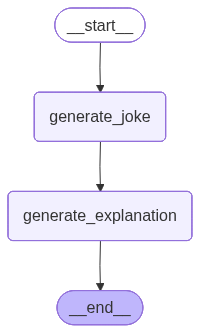

In [ ]:

workflow

In [ ]:
config1 = {"configurable":{"thread_id":"1"}}
workflow.invoke({"topic":"pizza"},config = config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" typically means being a bit irritable or grumpy, but in this case, it\'s also a pun on the fact that a pizza has a crust as part of its structure. The therapist, being unaware of this double meaning, might naturally assume that the pizza is feeling irritable, but the punchline reveals that the pizza\'s crust is literally what\'s making it feel the way it does. \n\nThis kind of wordplay is often referred to as a "pun," which is a form of humor that relies on multiple meanings or sounds of words. In this case, the joke relies on the fact that "crusty" can have both a literal and figurative meaning, creating a clever and amusing connection between the setup and the punchline.'}

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" typically means being a bit irritable or grumpy, but in this case, it\'s also a pun on the fact that a pizza has a crust as part of its structure. The therapist, being unaware of this double meaning, might naturally assume that the pizza is feeling irritable, but the punchline reveals that the pizza\'s crust is literally what\'s making it feel the way it does. \n\nThis kind of wordplay is often referred to as a "pun," which is a form of humor that relies on multiple meanings or sounds of words. In this case, the joke relies on the fact that "crusty" can have both a literal and figurative meaning, creating a clever and amusing connection between the setup and the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1537f9-9c13

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" typically means being a bit irritable or grumpy, but in this case, it\'s also a pun on the fact that a pizza has a crust as part of its structure. The therapist, being unaware of this double meaning, might naturally assume that the pizza is feeling irritable, but the punchline reveals that the pizza\'s crust is literally what\'s making it feel the way it does. \n\nThis kind of wordplay is often referred to as a "pun," which is a form of humor that relies on multiple meanings or sounds of words. In this case, the joke relies on the fact that "crusty" can have both a literal and figurative meaning, creating a clever and amusing connection between the setup and the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1537f9-9c1

In [ ]:
config2 = {"configurable":{
    "thread_id":"2"
}}
workflow.invoke({"topic":"pasta"},config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."',
 'explanation': 'The joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn the context of the joke, "twisted" refers to the physical shape of spaghetti, which is a long, curved and twisted strand of pasta. This is a common characteristic of spaghetti, and the speaker is making a wordplay on this.\n\nHowever, the phrase "feeling a little twisted" also has a common idiomatic meaning in everyday language, which refers to feeling emotionally disturbed or having mental health issues. People often describe themselves as feeling "twisted" or "off" when they are experiencing anxiety, depression, or other mental health concerns.\n\nThe joke relies on this wordplay to create a pun, where the speaker is using the literal meaning of "twisted" (to describe the spaghetti) and combining it with the idiomatic meaning (to describe the spaghetti\'s

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" typically means being a bit irritable or grumpy, but in this case, it\'s also a pun on the fact that a pizza has a crust as part of its structure. The therapist, being unaware of this double meaning, might naturally assume that the pizza is feeling irritable, but the punchline reveals that the pizza\'s crust is literally what\'s making it feel the way it does. \n\nThis kind of wordplay is often referred to as a "pun," which is a form of humor that relies on multiple meanings or sounds of words. In this case, the joke relies on the fact that "crusty" can have both a literal and figurative meaning, creating a clever and amusing connection between the setup and the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1537f9-9c13

In [ ]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn the context of the joke, "twisted" refers to the physical shape of spaghetti, which is a long, curved and twisted strand of pasta. This is a common characteristic of spaghetti, and the speaker is making a wordplay on this.\n\nHowever, the phrase "feeling a little twisted" also has a common idiomatic meaning in everyday language, which refers to feeling emotionally disturbed or having mental health issues. People often describe themselves as feeling "twisted" or "off" when they are experiencing anxiety, depression, or other mental health concerns.\n\nThe joke relies on this wordplay to create a pun, where the speaker is using the literal meaning of "twisted" (to describe the spaghetti) and combining it with the idiomatic meaning (to descri

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" typically means being a bit irritable or grumpy, but in this case, it\'s also a pun on the fact that a pizza has a crust as part of its structure. The therapist, being unaware of this double meaning, might naturally assume that the pizza is feeling irritable, but the punchline reveals that the pizza\'s crust is literally what\'s making it feel the way it does. \n\nThis kind of wordplay is often referred to as a "pun," which is a form of humor that relies on multiple meanings or sounds of words. In this case, the joke relies on the fact that "crusty" can have both a literal and figurative meaning, creating a clever and amusing connection between the setup and the punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1537f9-9c1

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. \n\nIn the context of the joke, "twisted" refers to the physical shape of spaghetti, which is a long, curved and twisted strand of pasta. This is a common characteristic of spaghetti, and the speaker is making a wordplay on this.\n\nHowever, the phrase "feeling a little twisted" also has a common idiomatic meaning in everyday language, which refers to feeling emotionally disturbed or having mental health issues. People often describe themselves as feeling "twisted" or "off" when they are experiencing anxiety, depression, or other mental health concerns.\n\nThe joke relies on this wordplay to create a pun, where the speaker is using the literal meaning of "twisted" (to describe the spaghetti) and combining it with the idiomatic meaning (to descr

# **Time Travel**

In [ ]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f15380e-828c-6dd1-bfff-c3fd0857bf93"}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f15380e-828c-6dd1-bfff-c3fd0857bf93'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-05-19T12:47:34.110347+00:00', parent_config=None, tasks=(PregelTask(id='8b14336e-8d75-af33-1ac6-152e27dc89cd', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'pasta'}),), interrupts=())

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f15380e-828c-6dd1-bfff-c3fd0857bf93"}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti join a band? \n\nBecause it wanted to be the saucy lead singer.',
 'explanation': 'The joke relies on a play on words and a pun. "Saucy" has a double meaning here. In the context of music, a "saucy" lead singer could imply that the singer is confident, charismatic, and perhaps a bit provocative. However, "saucy" also refers to the type of sauce commonly used with spaghetti, such as marinara or tomato sauce.\n\nThe joke is funny because it takes the typical expectation of what a lead singer might be like and replaces it with a word that\'s closely associated with spaghetti. It\'s a clever and lighthearted play on words that uses the connection between the food and the music to create a humorous effect.'}

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti join a band? \n\nBecause it wanted to be the saucy lead singer.', 'explanation': 'The joke relies on a play on words and a pun. "Saucy" has a double meaning here. In the context of music, a "saucy" lead singer could imply that the singer is confident, charismatic, and perhaps a bit provocative. However, "saucy" also refers to the type of sauce commonly used with spaghetti, such as marinara or tomato sauce.\n\nThe joke is funny because it takes the typical expectation of what a lead singer might be like and replaces it with a word that\'s closely associated with spaghetti. It\'s a clever and lighthearted play on words that uses the connection between the food and the music to create a humorous effect.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153820-27db-6af5-8003-e960619ef9c7'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-19T12:55

In [ ]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f15380e-828c-6dd1-bfff-c3fd0857bf93", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f153827-f6f3-6713-8000-87a3de7ba78d'}}

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153827-f6f3-6713-8000-87a3de7ba78d'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-05-19T12:58:57.404422+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15380e-828c-6dd1-bfff-c3fd0857bf93'}}, tasks=(PregelTask(id='153f9a40-37f0-689a-1831-ca7aac47da36', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti join a band? \n\nBecause it wanted to be the saucy lead singer.', 'explanation': 'The joke relies on a play on words and a pun. "Saucy" has a double meaning here. In the context of music, a "saucy" lead singer could imply that the singer is confident, charismatic, and perhaps a bit provocative. However, "sa

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f15380e-84d3-62da-8001-804a21702bbc"}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."',
 'explanation': 'This joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. In one sense, it refers to the emotional state of someone who is upset or struggling with their feelings, which is why they are going to therapy. However, "twisted" can also refer to the physical shape of spaghetti, which is a long, curly, and twisted strand of pasta.\n\nThe humor in the joke comes from the unexpected connection made between the emotional state of the spaghetti and its physical characteristics. It\'s a clever and lighthearted pun that uses wordplay to create a humorous effect.'}

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."', 'explanation': 'This joke is a play on words. The phrase "feeling a little twisted" has a double meaning here. In one sense, it refers to the emotional state of someone who is upset or struggling with their feelings, which is why they are going to therapy. However, "twisted" can also refer to the physical shape of spaghetti, which is a long, curly, and twisted strand of pasta.\n\nThe humor in the joke comes from the unexpected connection made between the emotional state of the spaghetti and its physical characteristics. It\'s a clever and lighthearted pun that uses wordplay to create a humorous effect.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15382d-a11a-6c43-8003-3faa1fa45cdb'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-19T13:01:29.464075+00:00', parent_config={'c

# **Fault Tolerance**

In [60]:
class CrashState(TypedDict):
    input:str
    step1:str
    step2:str


In [61]:
def step_1(state: CrashState) -> CrashState:
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(100)
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("Step 3 executed")
    return {"done": True}

In [62]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

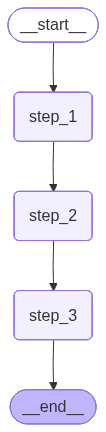

In [63]:
graph

In [64]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
Step 1 executed
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [68]:
# 6. Re-run to show fault-tolerant resume
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)

Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


KeyboardInterrupt: 

In [69]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))


[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f153847-5bee-649a-8001-bf2cd2664db1'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-19T13:13:00.142888+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f153847-5be8-6bb1-8000-c617ad38ef91'}}, tasks=(PregelTask(id='ddefc896-3389-df88-98ca-ebd7f98c4932', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f153847-5be8-6bb1-8000-c617ad38ef91'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-19T13:13:00.140606+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch